In [1]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import MinMaxScaler
import keras.preprocessing.image
from tensorflow.keras.preprocessing import image


# Load the preprocessed dataset
dataset = pd.read_csv("Crop_recommendation.csv")


# Convert the target variable into numerical values
crop_mapping = {
    "rice": 0, "maize": 1, "chickpea": 2, "kidneybeans": 3, "pigeonpeas": 4, "mothbeans": 5, "mungbean": 6,
    "blackgram": 7, "lentil": 8, "pomegranate": 9, "banana": 10, "mango": 11, "grapes": 12, "watermelon": 13,
    "muskmelon": 14, "apple": 15, "orange": 16, "papaya": 17, "coconut": 18, "cotton": 19, "jute": 20,
    "coffee": 21
}



C:\Users\ASUS\anaconda3\code\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.1
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
X = dataset.drop("label", axis=1)
print(X.columns)
y = dataset["label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall'], dtype='object')


In [3]:
clf = SVC()

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9613636363636363
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        23
      banana       1.00      1.00      1.00        21
   blackgram       0.91      1.00      0.95        20
    chickpea       1.00      1.00      1.00        26
     coconut       1.00      1.00      1.00        27
      coffee       1.00      0.94      0.97        17
      cotton       0.85      1.00      0.92        17
      grapes       1.00      1.00      1.00        14
        jute       0.77      1.00      0.87        23
 kidneybeans       0.95      1.00      0.98        20
      lentil       0.79      1.00      0.88        11
       maize       1.00      0.86      0.92        21
       mango       1.00      1.00      1.00        19
   mothbeans       1.00      0.88      0.93        24
    mungbean       1.00      1.00      1.00        19
   muskmelon       1.00      1.00      1.00        17
      orange       1.00      1.00      1.00        1

In [4]:
clf = KNeighborsClassifier()

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9704545454545455
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        23
      banana       1.00      1.00      1.00        21
   blackgram       0.95      1.00      0.98        20
    chickpea       1.00      1.00      1.00        26
     coconut       1.00      1.00      1.00        27
      coffee       1.00      0.94      0.97        17
      cotton       0.94      1.00      0.97        17
      grapes       1.00      1.00      1.00        14
        jute       0.76      0.96      0.85        23
 kidneybeans       0.95      1.00      0.98        20
      lentil       0.85      1.00      0.92        11
       maize       1.00      0.95      0.98        21
       mango       1.00      1.00      1.00        19
   mothbeans       1.00      0.92      0.96        24
    mungbean       1.00      1.00      1.00        19
   muskmelon       1.00      1.00      1.00        17
      orange       1.00      1.00      1.00        1

Accuracy: 0.9840909090909091
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        23
      banana       1.00      1.00      1.00        21
   blackgram       0.95      1.00      0.98        20
    chickpea       1.00      1.00      1.00        26
     coconut       1.00      1.00      1.00        27
      coffee       1.00      1.00      1.00        17
      cotton       1.00      1.00      1.00        17
      grapes       1.00      1.00      1.00        14
        jute       0.91      0.87      0.89        23
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.92      1.00      0.96        11
       maize       1.00      1.00      1.00        21
       mango       1.00      1.00      1.00        19
   mothbeans       1.00      0.92      0.96        24
    mungbean       1.00      1.00      1.00        19
   muskmelon       1.00      1.00      1.00        17
      orange       1.00      1.00      1.00        1

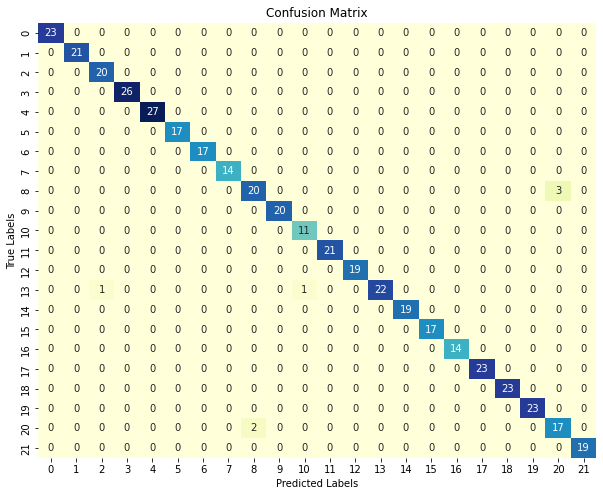

True Positives (TP): 21
True Negatives (TN): 23
False Positives (FP): 0
False Negatives (FN): 0


In [5]:
# Create a decision tree classifier
dt = DecisionTreeClassifier()

# Fit the model to the training data
dt.fit(X_train, y_train)

# Predict the labels of the test data
y_pred = dt.predict(X_test)

# Evaluate the model's performance
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Create a confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, cmap="YlGnBu", fmt="d", cbar=False)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()
# Extract TP, TN, FP, and FN from the confusion matrix
TP = cm[1, 1]  # True Positives
TN = cm[0, 0]  # True Negatives
FP = cm[0, 1]  # False Positives
FN = cm[1, 0]  # False Negatives

# Print TP, TN, FP, and FN
print("True Positives (TP):", TP)
print("True Negatives (TN):", TN)
print("False Positives (FP):", FP)
print("False Negatives (FN):", FN)

In [6]:
# Create a random forest classifier
clf = RandomForestClassifier(n_estimators=100, max_depth=5)

# Fit the model to the training data
clf.fit(X_train, y_train)

# Predict the labels of the test data
y_pred = clf.predict(X_test)

# Evaluate the model's performance
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9727272727272728
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        23
      banana       1.00      1.00      1.00        21
   blackgram       0.74      1.00      0.85        20
    chickpea       1.00      1.00      1.00        26
     coconut       1.00      1.00      1.00        27
      coffee       1.00      1.00      1.00        17
      cotton       0.94      1.00      0.97        17
      grapes       1.00      1.00      1.00        14
        jute       0.96      0.96      0.96        23
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.85      1.00      0.92        11
       maize       1.00      0.95      0.98        21
       mango       1.00      1.00      1.00        19
   mothbeans       1.00      0.67      0.80        24
    mungbean       1.00      1.00      1.00        19
   muskmelon       1.00      1.00      1.00        17
      orange       1.00      1.00      1.00        1

In [7]:
N = float(input("Enter the value of Nitrogen: "))
P = float(input("Enter the value of Phosphoras: "))
K = float(input("Enter the value of Potassium: "))
Temp = float(input("Enter the value of Temparature: "))
Humidity = float(input("Enter the value of Humidity: "))
PH = float(input("Enter the value of PH: "))
RainFall = float(input("Enter the value of Rainfall: "))



# Predict with sample input
sample_input = [[N, P, K, Temp, Humidity, PH, RainFall]]
prediction = clf.predict(sample_input)

# Print the prediction
print("Predicted crop:", prediction)


Enter the value of Nitrogen: 36
Enter the value of Phosphoras: 24
Enter the value of Potassium: 55
Enter the value of Temparature: 54
Enter the value of Humidity: 4
Enter the value of PH: 9
Enter the value of Rainfall: 2
Predicted crop: ['muskmelon']


C:\Users\ASUS\anaconda3\code\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder

# Assuming you have already loaded the dataset
df = pd.read_csv("Yeild.csv")
print(df.columns)

# Split the dataset into input features (X) and output target (y)
X = df[['Crop', 'Hectare']]
y = df['Metric Ton']

# Apply Label Encoding to the 'Crop' column
label_encoder = LabelEncoder()
X['Crop'] = label_encoder.fit_transform(X['Crop'])

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Index(['Crop', 'Hectare', 'Metric Ton'], dtype='object')


C:\Users\ASUS\AppData\Local\Temp\ipykernel_8080\212311918.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Crop'] = label_encoder.fit_transform(X['Crop'])


In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import LabelEncoder

# Assuming you have already loaded the dataset
df = pd.read_csv("Yeild.csv")
print(df.columns)

# Split the dataset into input features (X) and output target (y)
X = df[['Crop', 'Hectare']]
y = df['Metric Ton']

# Apply Label Encoding to the 'Crop' column
label_encoder = LabelEncoder()
X['Crop'] = label_encoder.fit_transform(X['Crop'])

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Random Forest Regressor model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict the labels of the test data
y_pred = model.predict(X_test)

# Evaluate the model using regression metrics
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

# Get user input
user_crop = input("Enter the Crop: ")
user_hectare = float(input("Enter the Hectare: "))

# Transform user input for Crop using label encoder
user_crop_encoded = label_encoder.transform([user_crop])

# Prepare the input data for prediction
user_input = pd.DataFrame({'Crop': user_crop_encoded, 'Hectare': [user_hectare]})

# Make predictions
predicted_metric_ton = model.predict(user_input)

print("Predicted Metric Ton:", predicted_metric_ton[0])


Index(['Crop', 'Hectare', 'Metric Ton'], dtype='object')


C:\Users\ASUS\AppData\Local\Temp\ipykernel_8080\573795535.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Crop'] = label_encoder.fit_transform(X['Crop'])


Mean Squared Error: 53432.18158789767
Enter the Crop: apple
Enter the Hectare: 2
Predicted Metric Ton: 37.384899999999995


Index(['Crop', 'Hectare', 'Metric Ton'], dtype='object')


C:\Users\ASUS\AppData\Local\Temp\ipykernel_8080\1672205028.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Crop'] = label_encoder.fit_transform(X['Crop'])


Mean Squared Error: 53432.18158789767
Enter the Crop: apple
Enter the Hectare: 6
Predicted Metric Ton: 40.189099999999975


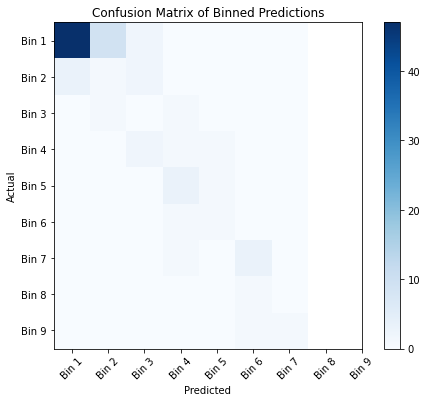

In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import numpy as np

# Assuming you have already loaded the dataset
df = pd.read_csv("Yeild.csv")
print(df.columns)

# Split the dataset into input features (X) and output target (y)
X = df[['Crop', 'Hectare']]
y = df['Metric Ton']

# Apply Label Encoding to the 'Crop' column
label_encoder = LabelEncoder()
X['Crop'] = label_encoder.fit_transform(X['Crop'])

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Random Forest Regressor model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict the labels of the test data
y_pred = model.predict(X_test)

# Evaluate the model using regression metrics
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

# Get user input
user_crop = input("Enter the Crop: ")
user_hectare = float(input("Enter the Hectare: "))

# Transform user input for Crop using label encoder
user_crop_encoded = label_encoder.transform([user_crop])

# Prepare the input data for prediction
user_input = pd.DataFrame({'Crop': user_crop_encoded, 'Hectare': [user_hectare]})

# Make predictions
predicted_metric_ton = model.predict(user_input)

print("Predicted Metric Ton:", predicted_metric_ton[0])

# Visualize predicted vs. actual values within different bins
# Create bins for actual values
bins = np.linspace(min(y_test), max(y_test), 10)
group_names = [f"Bin {i}" for i in range(1, len(bins))]

# Assign each sample to a bin
y_test_binned = pd.cut(y_test, bins, labels=group_names, include_lowest=True)
y_pred_binned = pd.cut(y_pred, bins, labels=group_names, include_lowest=True)

# Create a confusion matrix
confusion_matrix = pd.crosstab(y_test_binned, y_pred_binned, rownames=['Actual'], colnames=['Predicted'])

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
plt.imshow(confusion_matrix, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix of Binned Predictions')
plt.colorbar()
tick_marks = np.arange(len(group_names))
plt.xticks(tick_marks, group_names, rotation=45)
plt.yticks(tick_marks, group_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder

# Assuming you have already loaded the dataset
df = pd.read_csv("Yeild.csv")
print(df.columns)

# Split the dataset into input features (X) and output target (y)
X = df[['Crop', 'Hectare']]
y = df['Metric Ton']

# Apply Label Encoding to the 'Crop' column
label_encoder = LabelEncoder()
X['Crop'] = label_encoder.fit_transform(X['Crop'])

# Convert regression problem into classification by rounding
y_class = (y > y.mean()).astype(int)  # Using a threshold, adjust as needed

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_class, test_size=0.2, random_state=42)

# Initialize and train the Random Forest Regressor model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict the labels of the test data
y_pred = (model.predict(X_test) > y.mean()).astype(int)

# Print the classification report
print(classification_report(y_test, y_pred))


Index(['Crop', 'Hectare', 'Metric Ton'], dtype='object')
              precision    recall  f1-score   support

           0       0.75      1.00      0.86        62
           1       0.00      0.00      0.00        21

    accuracy                           0.75        83
   macro avg       0.37      0.50      0.43        83
weighted avg       0.56      0.75      0.64        83



C:\Users\ASUS\AppData\Local\Temp\ipykernel_8080\318773400.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Crop'] = label_encoder.fit_transform(X['Crop'])
C:\Users\ASUS\anaconda3\code\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\ASUS\anaconda3\code\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf

In [18]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder

# Assuming you have already loaded the dataset
df = pd.read_csv("Yeild.csv")
print(df.columns)

# Split the dataset into input features (X) and output target (y)
X = df[['Crop', 'Hectare']]
y = df['Metric Ton']

# Apply Label Encoding to the 'Crop' column
label_encoder = LabelEncoder()
X['Crop'] = label_encoder.fit_transform(X['Crop'])

# Convert regression problem into classification by rounding
threshold = 0.98  # Adjust the threshold as needed
y_class = (y > y.quantile(threshold)).astype(int)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_class, test_size=0.2, random_state=42)

# Initialize and train the Decision Tree Regressor model
model = DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train)

# Predict the labels of the test data
y_pred = (model.predict(X_test) > y.quantile(threshold)).astype(int)

# Print the classification report
print(classification_report(y_test, y_pred))


Index(['Crop', 'Hectare', 'Metric Ton'], dtype='object')
              precision    recall  f1-score   support

           0       0.99      1.00      0.99        82
           1       0.00      0.00      0.00         1

    accuracy                           0.99        83
   macro avg       0.49      0.50      0.50        83
weighted avg       0.98      0.99      0.98        83



C:\Users\ASUS\AppData\Local\Temp\ipykernel_8080\889612807.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Crop'] = label_encoder.fit_transform(X['Crop'])
C:\Users\ASUS\anaconda3\code\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\ASUS\anaconda3\code\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf